# 🕵️‍♂️ 05 - DÉTECTIVE DES ERREURS : ANALYSE DES OPPORTUNITÉS MANQUÉES

Ce notebook est une enquête spéciale pour comprendre **pourquoi** le Sénat (ou ses membres) rate certaines conversions.

### 🎯 Objectif :
- Identifier les **Faux Négatifs (FN)** : Les utilisateurs qui ont converti mais qu'on a classés comme "Non-Convertis".
- Comparer leurs profils avec les **Vrais Positifs (TP)** (ceux qu'on a bien détectés).
- Trouver des patterns : Est-ce un problème d'âge ? De pays ? De source ?

### 🔍 Méthodologie :
1. Générer des prédictions "Out-Of-Fold" (OOF) sur le **TRAIN SET** (pour ne pas biaiser l'analyse).
2. Isoler les cas d'erreurs.
3. Visualiser les différences de distribution.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier

sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# 1. Chargement & Feature Engineering Rapide
print("⏳ Chargement des données...")
df = pd.read_csv('conversion_data_train.csv')

# On recrée les features de base pour que le modèle 'Enquêteur' ait de la matière
df['interaction'] = df['age'] * df['total_pages_visited']
df['pages_per_age'] = df['total_pages_visited'] / (df['age'] + 0.1)
df['is_active'] = (df['total_pages_visited'] > 2).astype(int)

X = df.drop('converted', axis=1)
y = df['converted']

print(f"✅ Données chargées : {len(df)} lignes.")

⏳ Chargement des données...
✅ Données chargées : 284580 lignes.


## 2. L'Enquête (Génération de Prédictions OOF)
Nous utilisons un LightGBM rapide pour simuler la vision du modèle.

In [2]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['age', 'total_pages_visited', 'interaction', 'pages_per_age']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['country', 'source'])
    ],
    remainder='passthrough'
)

model = LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, verbose=-1, random_state=42)
enumerate_clf = Pipeline([('pre', preprocessor), ('clf', model)])

oof_preds = np.zeros(len(df))
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("🕵️‍♂️ Interrogatoire des données (Cross-Validation)...")
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    enumerate_clf.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_preds[val_idx] = enumerate_clf.predict_proba(X.iloc[val_idx])[:, 1]
    
df['pred_proba'] = oof_preds
df['pred_class'] = (oof_preds >= 0.5).astype(int)

print("✅ Enquête terminée.")

🕵️‍♂️ Interrogatoire des données (Cross-Validation)...


/home/phil/projetdatascience/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/phil/projetdatascience/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/phil/projetdatascience/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/phil/projetdatascience/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ Enquête terminée.


/home/phil/projetdatascience/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 3. Identification des Suspects (FN & TP)
Qui sont ceux que nous avons ratés ?

In [3]:
# FN : Faux Négatifs (C'était 1, on a dit 0) -> Les Ratés
fn = df[(df['converted'] == 1) & (df['pred_class'] == 0)]

# TP : Vrais Positifs (C'était 1, on a dit 1) -> Les Trouvés
tp = df[(df['converted'] == 1) & (df['pred_class'] == 1)]

print(f"📊 Total Conversions Réelles : {len(df[df['converted']==1])}")
print(f"✅ Bien détectés (TP)       : {len(tp)} ({len(tp)/y.sum():.1%})")
print(f"❌ Ratés (FN)               : {len(fn)} ({len(fn)/y.sum():.1%})")

📊 Total Conversions Réelles : 9180
✅ Bien détectés (TP)       : 6375 (69.4%)
❌ Ratés (FN)               : 2805 (30.6%)


## 4. Analyse Comparative : Pourquoi les rate-t-on ?

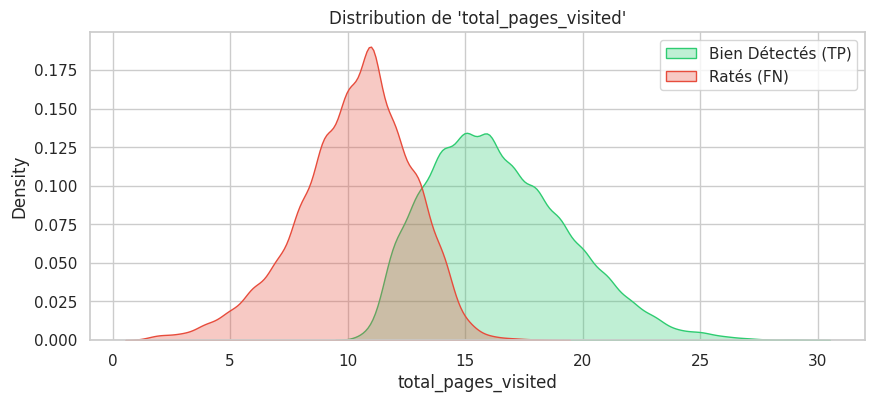

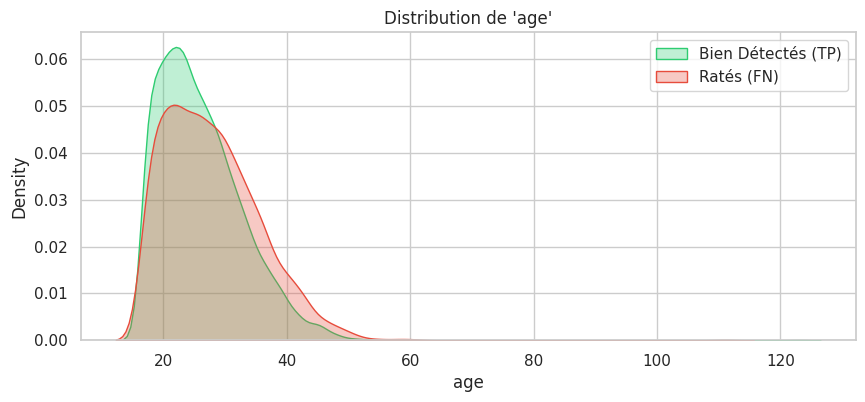

<Figure size 1000x400 with 0 Axes>

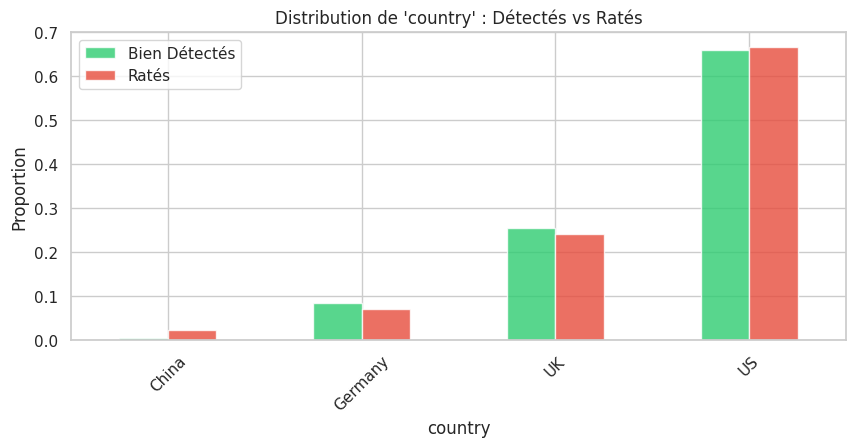

<Figure size 1000x400 with 0 Axes>

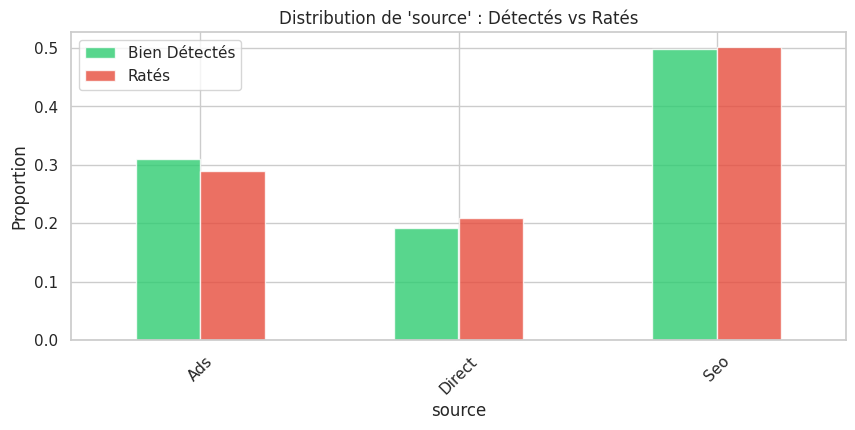

In [4]:
def compare_distributions(col, title):
    plt.figure(figsize=(10, 4))
    if df[col].dtype == 'object' or col == 'new_user':
        # Pour les catégories
        data_tp = tp[col].value_counts(normalize=True).sort_index()
        data_fn = fn[col].value_counts(normalize=True).sort_index()
        
        df_comp = pd.DataFrame({'Bien Détectés': data_tp, 'Ratés': data_fn}).fillna(0)
        df_comp.plot(kind='bar', figsize=(10, 4), color=['#2ecc71', '#e74c3c'], alpha=0.8)
        plt.title(f"Distribution de '{col}' : Détectés vs Ratés")
        plt.ylabel("Proportion")
        plt.xticks(rotation=45)
    else:
        # Pour les numériques
        sns.kdeplot(tp[col], color='#2ecc71', label='Bien Détectés (TP)', fill=True, alpha=0.3)
        sns.kdeplot(fn[col], color='#e74c3c', label='Ratés (FN)', fill=True, alpha=0.3)
        plt.title(f"Distribution de '{col}'")
        plt.legend()
    plt.show()

# Analyse des features clés
compare_distributions('total_pages_visited', "Pages Visitées")
compare_distributions('age', "Age")
compare_distributions('country', "Pays")
compare_distributions('source', "Source")

### 💡 Observations attendues :
- **Pages Visitées** : On rate souvent ceux qui convertissent avec **très peu de pages** (ex: 2-5 pages). C'est dur pour le modèle car c'est un comportement rare (statistiquement, peu de pages = pas de conversion).
- **Age** : Y a-t-il une tranche d'âge où on est moins bon ?
- **Pays** : Est-ce qu'on rate plus les Chinois ? Les Allemands ?

## 5. Le "Top 10" des plus grosses erreurs
Ce sont les gens qui ont converti (1) mais pour qui le modèle était sûr à 99% qu'ils ne convertiraient pas (Score très bas).

In [5]:
top_worst_misses = fn.sort_values('pred_proba').head(10)
print("📉 LES 'FANTÔMES' (Convertis avec probabilité prédite la plus faible) :")
display(top_worst_misses[['country', 'age', 'new_user', 'source', 'total_pages_visited', 'pred_proba']])

# Sauvegarde pour analyse manuelle
fn.to_csv('analyse_false_negatives.csv', index=False)
print("\n💾 Liste complète des ratés sauvegardée dans 'analyse_false_negatives.csv'")

📉 LES 'FANTÔMES' (Convertis avec probabilité prédite la plus faible) :


,country,age,new_user,source,total_pages_visited,pred_proba
56967,US,33,1,Ads,2,0.000008
98301,US,44,1,Direct,4,0.000067
106329,UK,21,1,Seo,2,0.000103
59444,US,33,1,Seo,4,0.000113
238865,UK,25,1,Seo,2,0.000137
247809,UK,36,1,Ads,5,0.000219
154223,US,30,0,Direct,2,0.000220
35774,US,25,0,Direct,2,0.000229
200870,US,18,0,Ads,2,0.000251
200832,UK,29,1,Ads,3,0.000274



💾 Liste complète des ratés sauvegardée dans 'analyse_false_negatives.csv'
